## Name: Hadi Abu Allairat
## ID: 2230005761
## Section: 8MA1

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftfreq, fft2, ifftshift
from skimage import data
from skimage.transform import resize

## Load cameraman image (already grayscale)

In [2]:
image = data.camera()
image = resize(image, (256, 256)) # Resize for faster FFT (optional)

## Generate frequency grid (centered)

In [3]:
# Get image size
M, N = image.shape
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

## Compute Laplacian filter in frequency domain

In [4]:
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)
# Apply 2D FFT
F = np.fft.fft2(image)
# Apply Laplacian filter in the frequency domain
F_lap = F * laplacian_filter
# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

## Plot results

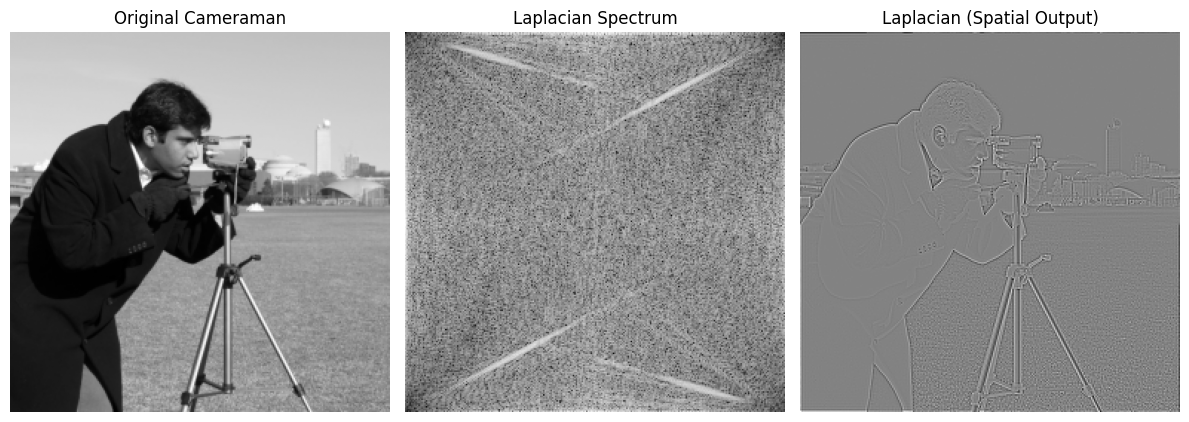

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 1: Using the same Cameraman image, apply the Sobel filter(s) in the frequency domain and show the results.

### Load and resize image

In [6]:
camera_man = data.camera()
camera_man = resize(image, (256, 256))

### Sobel filters

In [7]:

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]])


In [8]:
# Proper padding and centering of kernel in the spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded)) # Shift before FFT to place (0,0) at top-left

### Compute FFT of image

In [9]:
frequncy_image = np.fft.fft2(camera_man)
M, N = image.shape

### FFT of centered Sobel filters (use the provided function)

In [10]:
transformed_sorbel_filter_x = center_embed_kernel(sobel_x, camera_man.shape)
transformed_sorbel_filter_y = center_embed_kernel(sobel_y, camera_man.shape)

### Multiply in the frequency domain

In [11]:
frequncy_image_x = frequncy_image * transformed_sorbel_filter_x
frequncy_image_y = frequncy_image *  transformed_sorbel_filter_y

grad_x = np.fft.ifft2(frequncy_image_x).real
grad_y = np.fft.ifft2(frequncy_image_y).real

sorbel_image = np.sqrt(grad_x**2 + grad_y**2)

### Plot

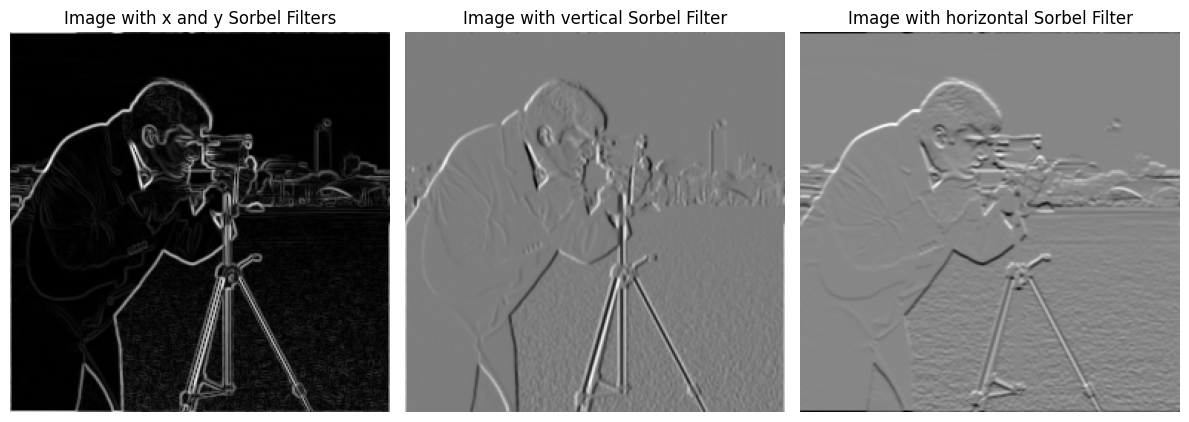

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(sorbel_image, cmap='gray')
plt.title('Image with x and y Sorbel Filters')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad_x, cmap='gray')
plt.title('Image with vertical Sorbel Filter')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(grad_y, cmap='gray')
plt.title('Image with horizontal Sorbel Filter')
plt.axis('off')

plt.tight_layout()
plt.show()